# LLM-Generated Natural Language Explanations for Deep Learning-Based Satellite Image Classification

## Setup and Configuration

### Install libraries

In [1]:
!pip install torch torchvision
!pip install grad-cam
!pip install openai
!pip install datasets
!pip install matplotlib seaborn
!pip install lime -q
!pip install shap -q

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3.12 -m pip install

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla V100-SXM2-32GB


### Import packages

In [3]:
# Standard Library
import io
import random
import base64
import os



# Data Handling
import numpy as np
import pandas as pd
from datasets import load_dataset
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.models as models

# Explainability — GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Explainability — LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries

# LLM Integration
import requests
from openai import OpenAI

print("All libraries imported successfully!")

All libraries imported successfully!


##  Dataset


### Load EuroSAT dataset

In [4]:
dataset = load_dataset("tanganke/eurosat", split="train")
print(dataset)
print(dataset.features)

Dataset({
    features: ['image', 'label'],
    num_rows: 21600
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea'])}


In [5]:
class_names = dataset.features['label'].names
print("Extracted class names:", class_names)

Extracted class names: ['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']


In [6]:
# Check dataset details
print("Dataset info:")
print(dataset)
print("\nNumber of samples:", len(dataset))
print("\nClass names:", class_names)
print("Number of classes:", len(class_names))

# Check a single sample
sample = dataset[0]
print("\nSample keys:", sample.keys())
print("Image size:", sample['image'].size)
print("Label:", class_names[sample['label']])

Dataset info:
Dataset({
    features: ['image', 'label'],
    num_rows: 21600
})

Number of samples: 21600

Class names: ['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']
Number of classes: 10

Sample keys: dict_keys(['image', 'label'])
Image size: (64, 64)
Label: annual crop land


### Sample visualization per Class

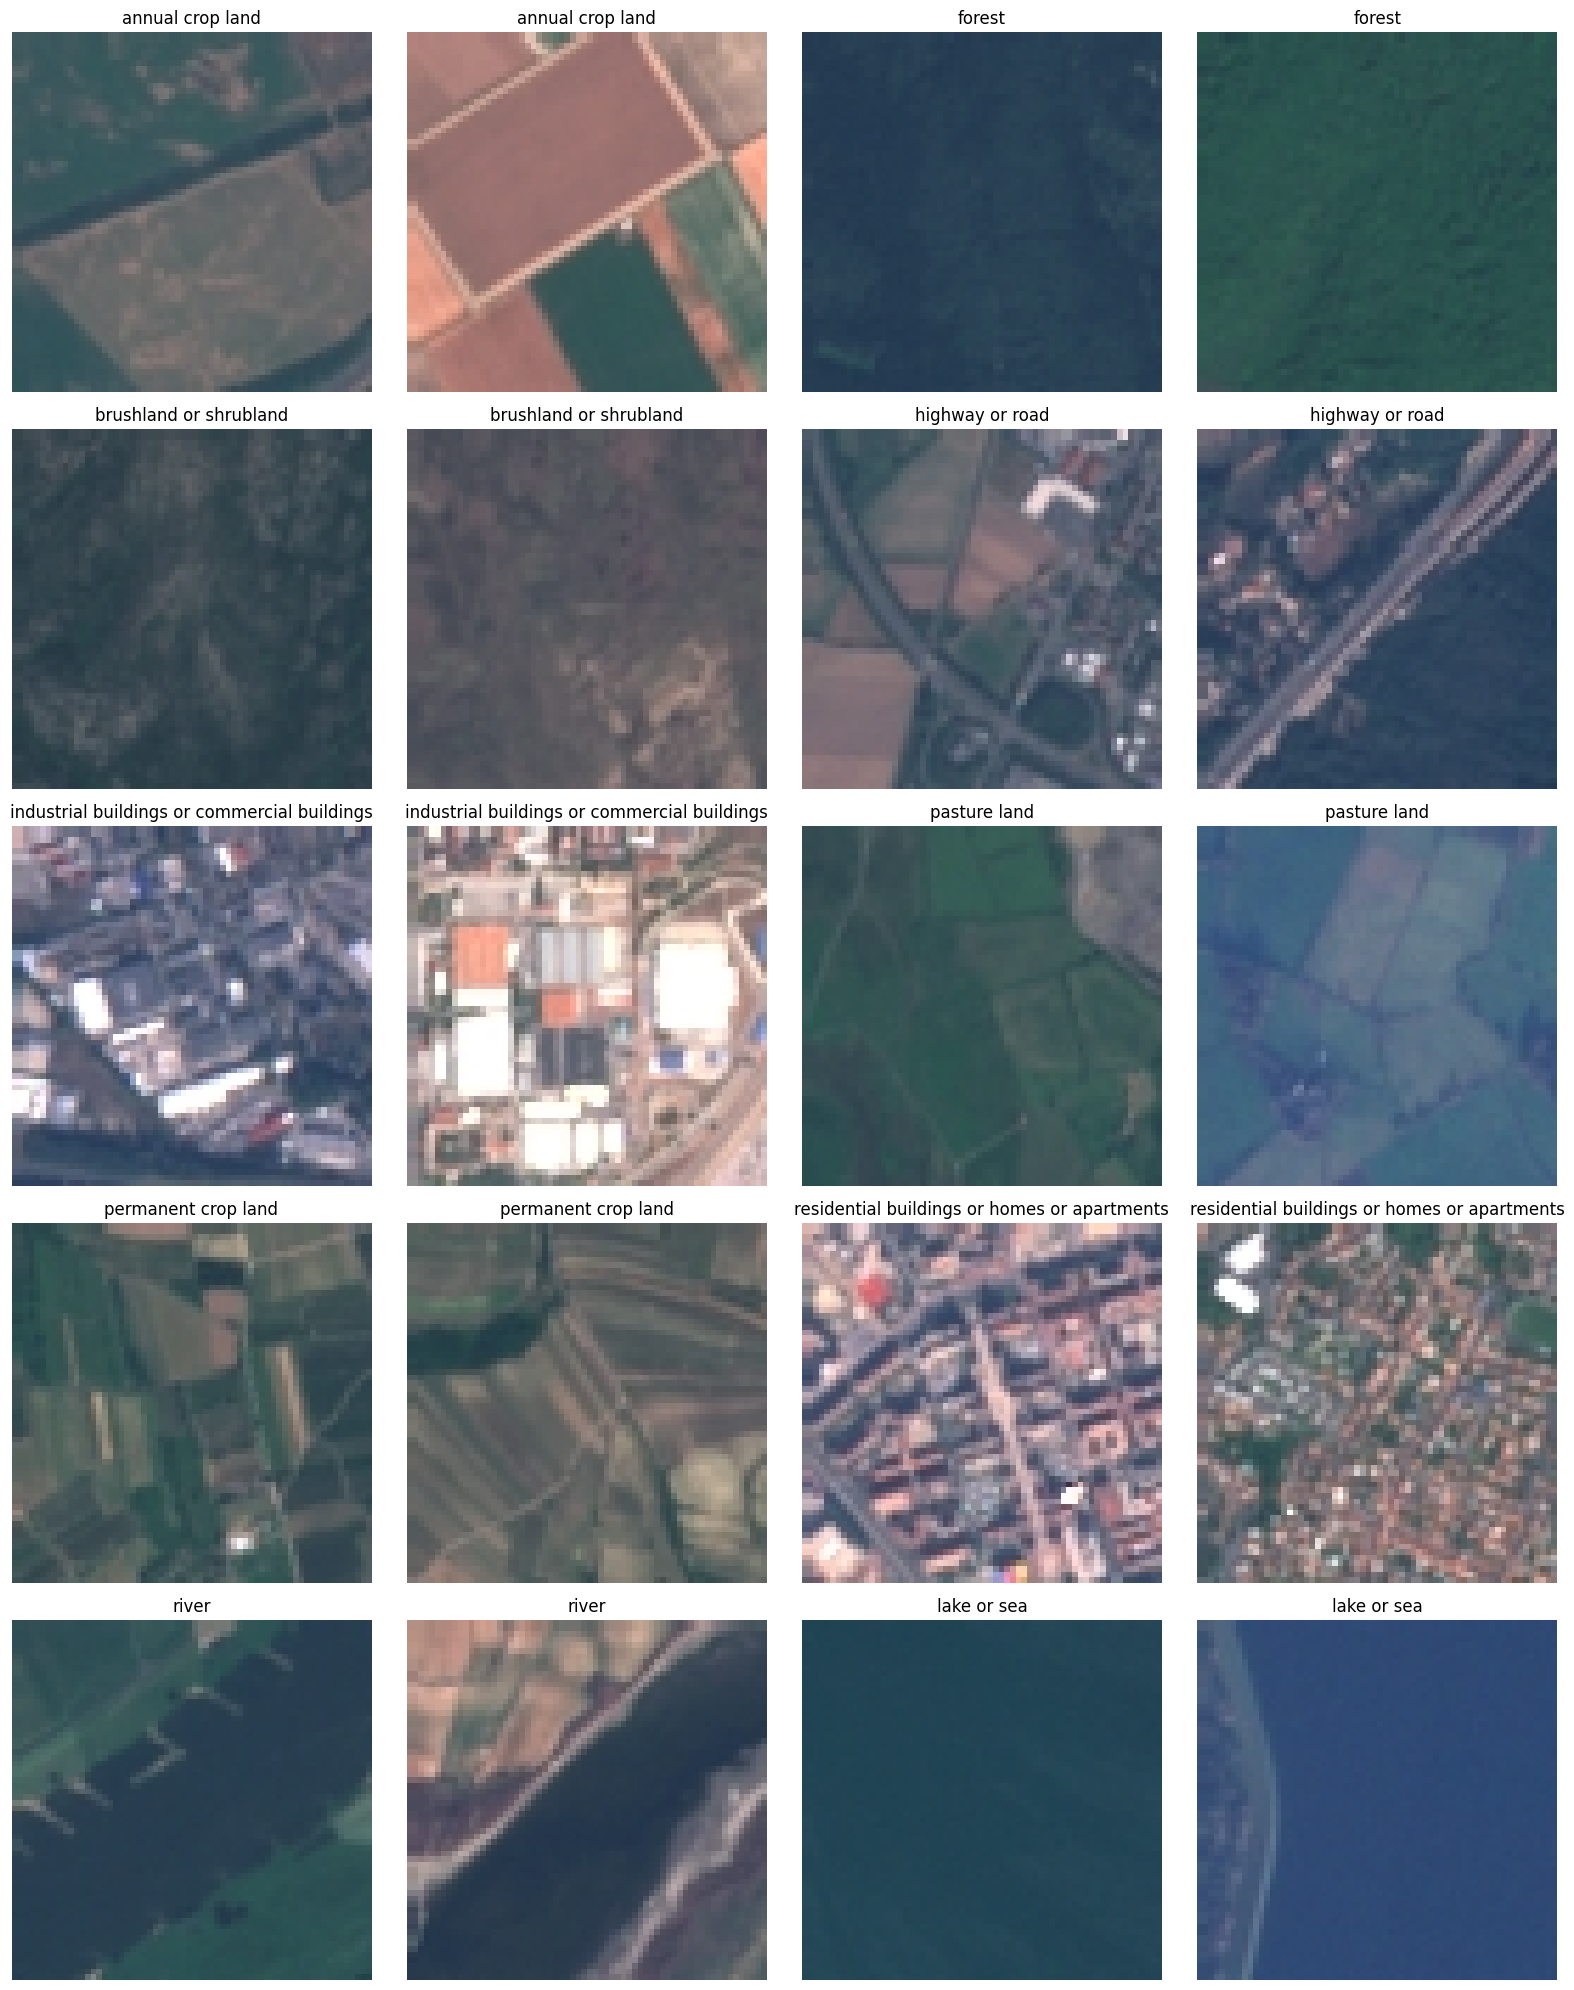

In [10]:
# Number of images to sample per class
num_samples_per_class = 2

# Calculate grid size (e.g., 10 classes * 2 images/class = 20 images, so a 5x4 grid)
num_classes = len(class_names)
num_rows = (num_classes * num_samples_per_class + 3) // 4 # Adjust to fit all images in a reasonable grid
num_cols = 4 # Fixed columns for a good layout

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))
axes = axes.flatten()

image_count = 0
for i, class_name in enumerate(class_names):
    # Filter dataset for the current class
    class_dataset = dataset.filter(lambda example: example['label'] == i)

    # Randomly sample images
    sampled_indices = random.sample(range(len(class_dataset)), min(num_samples_per_class, len(class_dataset)))

    for idx in sampled_indices:
        if image_count < len(axes):
            image = class_dataset[idx]['image']
            axes[image_count].imshow(image)
            axes[image_count].set_title(class_name)
            axes[image_count].axis('off') # Remove axes for cleaner visualization
            image_count += 1

# Turn off any unused subplots
for j in range(image_count, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Summary:


*   The generated plots provide a clear visual representation of the different land cover types in the EuroSAT dataset, allowing for an initial understanding of the visual characteristics and potential challenges for classification (e.g., distinguishing between similar-looking classes).


### Data preprocessing and transforms

In [7]:
# Retransform with larger image size
transform_large = transforms.Compose([
    transforms.Resize((224, 224)),  # Larger size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset_large = dataset.with_transform(
    lambda x: {'image': [transform_large(img) for img in x['image']],
                'label': x['label']}
)

split_large = dataset_large.train_test_split(test_size=0.2)
train_data_large = split_large['train']
val_data_large = split_large['test']

print(f"Training samples: {len(train_data_large)}")
print(f"Validation samples: {len(val_data_large)}")

Training samples: 17280
Validation samples: 4320


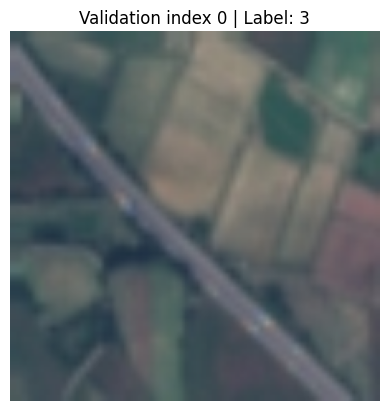

In [16]:
import matplotlib.pyplot as plt

sample = val_data_large[0]

image = sample["image"].permute(1, 2, 0).cpu().numpy()

# Undo normalization for correct display
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

image = image * std + mean
image = image.clip(0, 1)

plt.imshow(image)
plt.title(f"Validation index 0 | Label: {sample['label']}")
plt.axis("off")
plt.show()

## Classification Model

### Load pretrained ResNet50 (This step is not needed if the model is already saved)


What this code does

- Loads ResNet50 pretrained on ImageNet
- Freezes all existing layers, we don't retrain them, just reuse their knowledge
- Replaces only the final layer for our 10 EuroSAT classes
- Moves model to GPU for fast training

This approach is called Transfer Learning, instead of training from scratch which takes days, we reuse a model that already understands visual features and just teach it our specific classes. Very common and effective for satellite imagery.

In [11]:

# Fresh model
model = models.resnet50(weights='IMAGENET1K_V1')

for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Linear(2048, 10)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return images, labels

# Recreate dataloaders with larger images
train_loader_large = DataLoader(
    train_data_large,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_large = DataLoader(
    val_data_large,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Train
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_large:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct/total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_large:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss/len(train_loader_large):.3f} "
          f"Train Acc: {train_acc:.1f}% "
          f"Val Acc: {val_acc:.1f}%")

Epoch [1/10] Train Loss: 0.296 Train Acc: 90.7% Val Acc: 96.5%
Epoch [2/10] Train Loss: 0.129 Train Acc: 95.9% Val Acc: 97.1%
Epoch [3/10] Train Loss: 0.091 Train Acc: 97.0% Val Acc: 97.4%
Epoch [4/10] Train Loss: 0.064 Train Acc: 97.8% Val Acc: 96.4%
Epoch [5/10] Train Loss: 0.055 Train Acc: 98.2% Val Acc: 97.2%
Epoch [6/10] Train Loss: 0.034 Train Acc: 98.9% Val Acc: 97.5%
Epoch [7/10] Train Loss: 0.038 Train Acc: 98.7% Val Acc: 97.8%
Epoch [8/10] Train Loss: 0.028 Train Acc: 99.0% Val Acc: 97.3%
Epoch [9/10] Train Loss: 0.026 Train Acc: 99.2% Val Acc: 97.5%
Epoch [10/10] Train Loss: 0.024 Train Acc: 99.3% Val Acc: 98.0%


**Save the model**

In [12]:
torch.save(model.state_dict(),
    f'resnet_224.pth')
print("✓ Model saved!")

✓ Model saved!


### Load the model from saved file

In [8]:
model = models.resnet50(weights='IMAGENET1K_V1')

for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Linear(2048, 10)
model.load_state_dict(torch.load(f'resnet_224.pth'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()
print("Model loaded from saved file!")

Model loaded from saved file!


### A table of total accuracy, precision, recall and F1-score for all classes

In [14]:
def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return images, labels

# Recreate dataloaders with larger images
# train_loader_large = DataLoader(
#     train_data_large,
#     batch_size=32,
#     shuffle=True,
#     collate_fn=collate_fn
# )

val_loader_large = DataLoader(
    val_data_large,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

Running inference on validation set...
✓ Evaluated 4320 validation images

VALIDATION SET PERFORMANCE - PER CLASS METRICS
                                              Precision (%)  Recall (%)  F1-Score (%)  Support  Accuracy (%)
annual crop land                                      100.0        99.1          99.6      463          99.1
forest                                                 99.6        99.8          99.7      469          99.8
brushland or shrubland                                 99.8        99.8          99.8      510          99.8
highway or road                                        97.9       100.0          99.0      427         100.0
industrial buildings or commercial buildings           99.7        98.9          99.3      380          98.9
pasture land                                           98.8        99.1          98.9      320          99.1
permanent crop land                                    99.0        99.7          99.4      386          99.7
reside

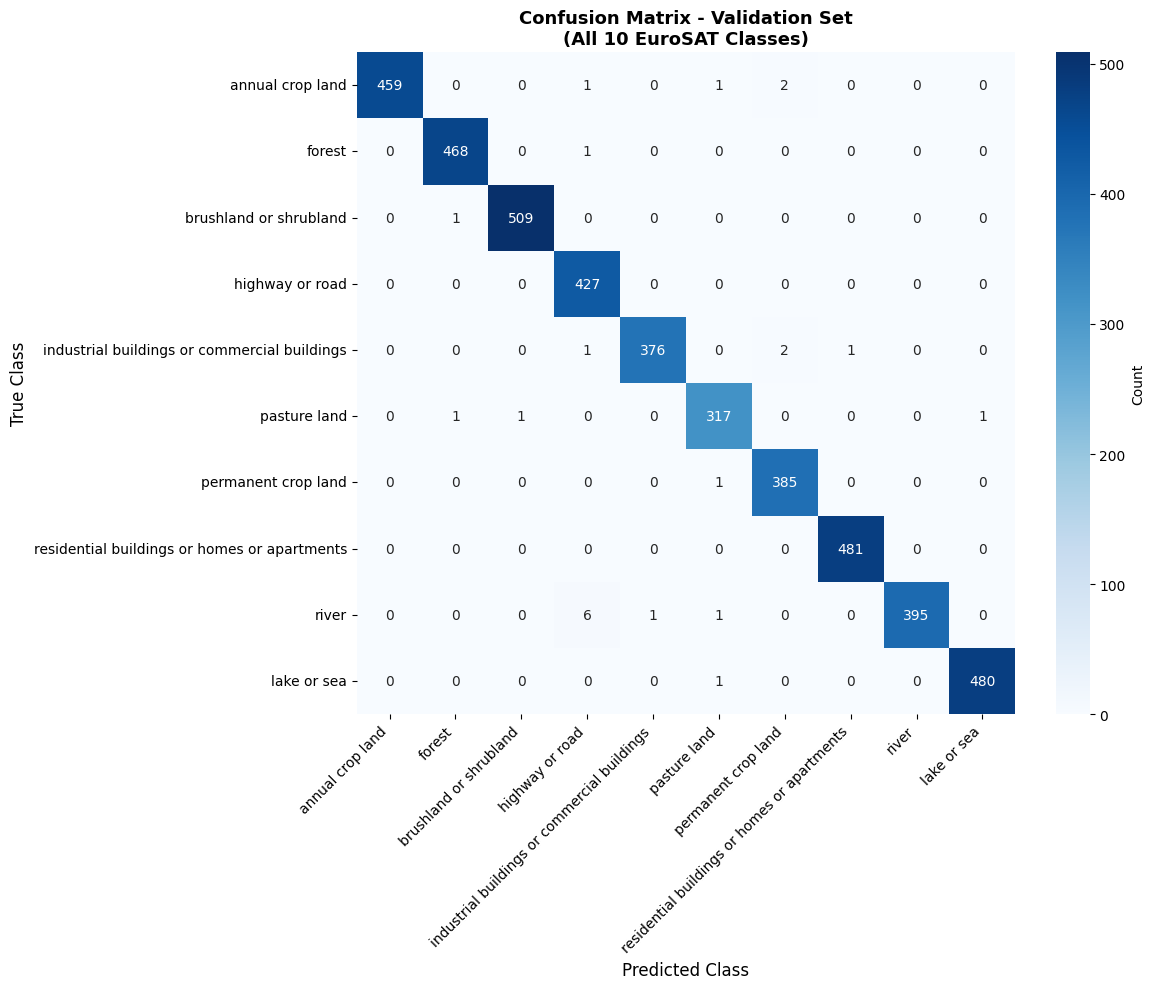

✓ Confusion matrix saved!


In [23]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# ── Get predictions on validation set ───────────────────────────────────
all_preds = []
all_labels = []

print("Running inference on validation set...")
with torch.no_grad():
    for images, labels in val_loader_large:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"✓ Evaluated {len(all_labels)} validation images")

# ── Generate classification report ──────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

# Get overall accuracy
overall_accuracy = accuracy_score(all_labels, all_preds) * 100

# Generate detailed report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame for nice display
report_df = pd.DataFrame(report).transpose()

# Extract per-class metrics
per_class_metrics = report_df.iloc[:-3]  # Exclude accuracy, macro avg, weighted avg rows
per_class_metrics = per_class_metrics[['precision', 'recall', 'f1-score', 'support']]
per_class_metrics['accuracy'] = [(all_preds[all_labels==i] == i).sum() / (all_labels==i).sum() * 100 
                                   for i in range(len(class_names))]

# Format for display
per_class_metrics['precision'] = (per_class_metrics['precision'] * 100).round(1)
per_class_metrics['recall'] = (per_class_metrics['recall'] * 100).round(1)
per_class_metrics['f1-score'] = (per_class_metrics['f1-score'] * 100).round(1)
per_class_metrics['accuracy'] = per_class_metrics['accuracy'].round(1)
per_class_metrics['support'] = per_class_metrics['support'].astype(int)

# Rename columns for clarity
per_class_metrics.columns = ['Precision (%)', 'Recall (%)', 'F1-Score (%)', 
                              'Support', 'Accuracy (%)']

# Print results
print("\n" + "="*80)
print("VALIDATION SET PERFORMANCE - PER CLASS METRICS")
print("="*80)
print(per_class_metrics.to_string())
print("="*80)

# Overall metrics
print(f"\nOverall Validation Accuracy: {overall_accuracy:.1f}%")
print(f"Macro Average Precision:     {report['macro avg']['precision']*100:.1f}%")
print(f"Macro Average Recall:        {report['macro avg']['recall']*100:.1f}%")
print(f"Macro Average F1-Score:      {report['macro avg']['f1-score']*100:.1f}%")

# Save to CSV
per_class_metrics.to_csv(f'validation_metrics.csv')
print(f"\n✓ Metrics saved to validation_metrics.csv")

# ── Confusion Matrix ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title('Confusion Matrix - Validation Set\n(All 10 EuroSAT Classes)', 
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'confusion_matrix_validation.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved!")

## Select 6 classes and 20 images per class

In [17]:
#  Selected classes only
selected_classes = [
    'annual crop land',
    'forest',
    'highway or road',
    'industrial buildings or commercial buildings',
    'residential buildings or homes or apartments',
    'river'
]

# Get class indices from full class list
selected_indices = [class_names.index(c) for c in selected_classes]

print("Selected classes and their indices:")
for name, idx in zip(selected_classes, selected_indices):
    print(f"  {idx}: {name}")
print(f"\nTotal images to process: {len(selected_classes)} classes × 20 images = {len(selected_classes)*20}")

Selected classes and their indices:
  0: annual crop land
  1: forest
  3: highway or road
  4: industrial buildings or commercial buildings
  7: residential buildings or homes or apartments
  8: river

Total images to process: 6 classes × 20 images = 120


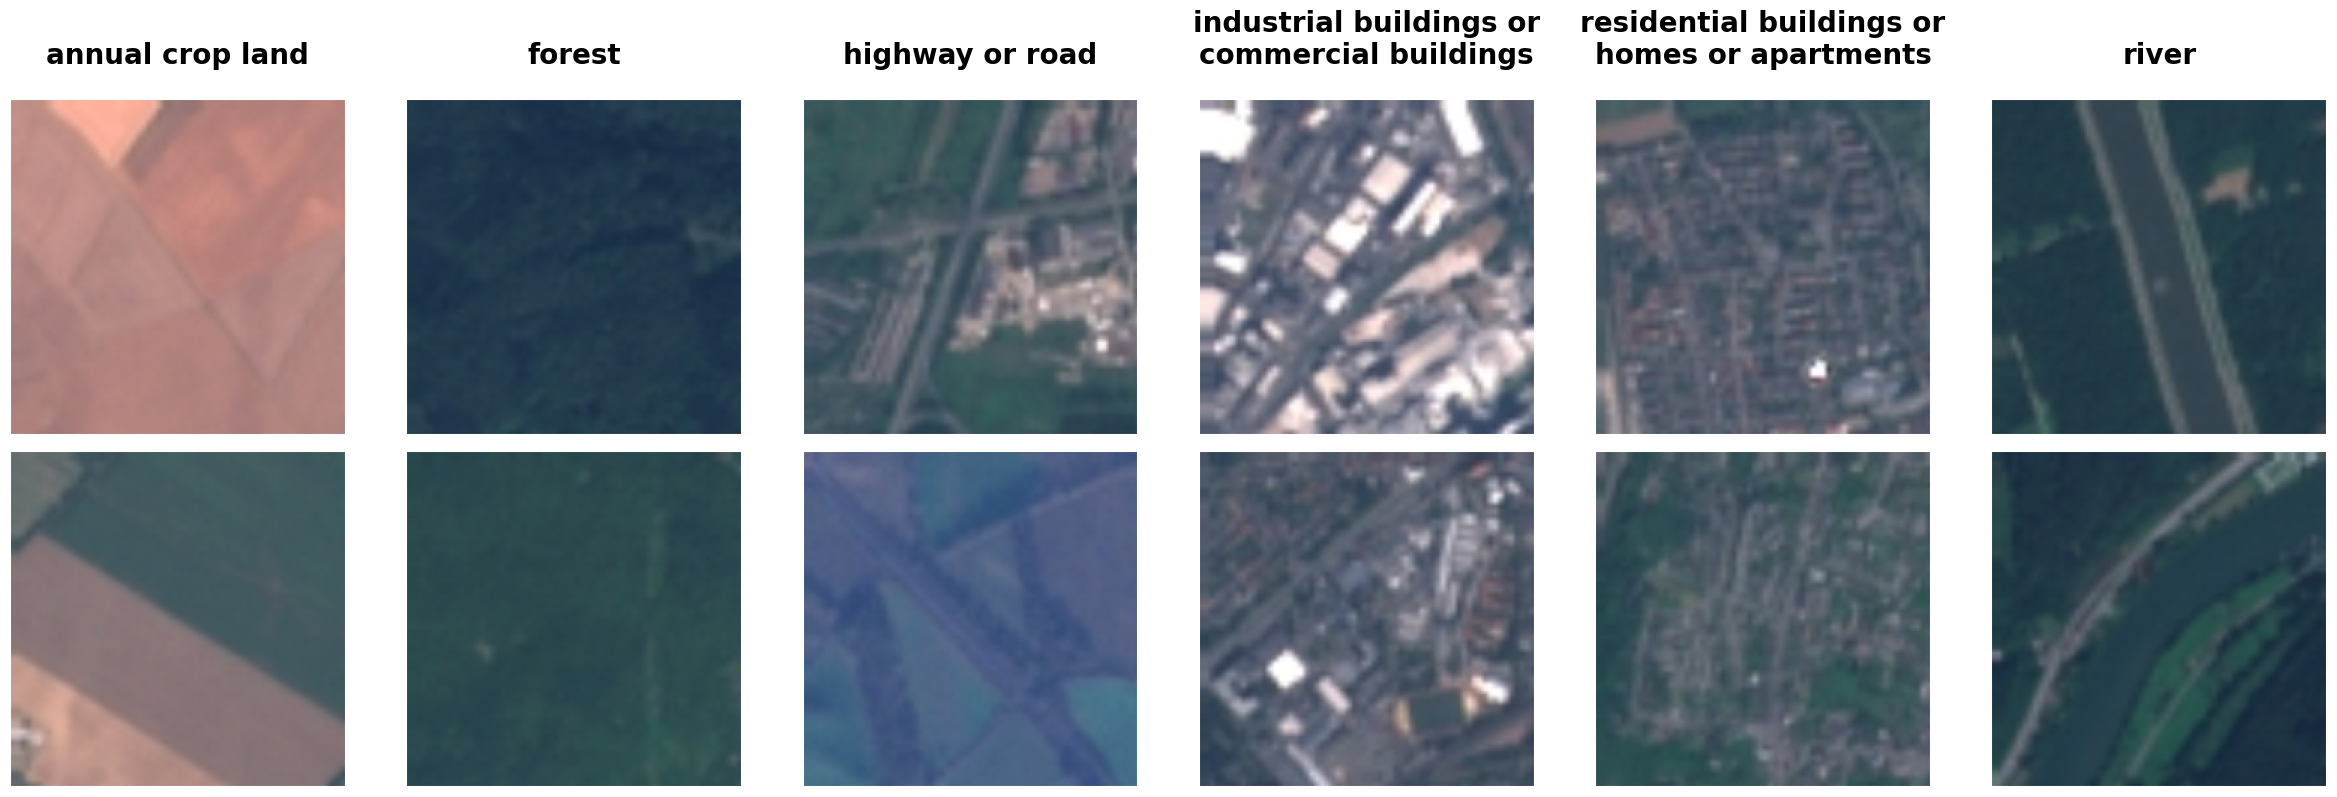

In [28]:
import matplotlib.pyplot as plt
import torch
import textwrap

# Number of images from each class
num_images_per_class = 2

# Function to unnormalize image for display
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    img_tensor = img_tensor * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    
    return img_tensor.permute(1, 2, 0)  # C,H,W -> H,W,C

# Create 2 rows × 6 columns
fig, axes = plt.subplots(
    num_images_per_class,
    len(selected_classes),
    figsize=(len(selected_classes) * 4, num_images_per_class * 4)
)

# White background, suitable for research paper
fig.patch.set_facecolor("white")

for col, (class_name, class_idx) in enumerate(zip(selected_classes, selected_indices)):
    
    # Get validation images belonging to this class
    class_dataset = val_data_large.filter(lambda example: example['label'] == class_idx)
    
    # Wrap long class names into multiple lines
    wrapped_class_name = textwrap.fill(class_name, width=25)
    
    # Take first 2 images from validation set
    for row in range(num_images_per_class):
        image = class_dataset[row]['image']
        
        # Unnormalize before showing
        image = unnormalize(image)
        
        axes[row, col].imshow(image)
        axes[row, col].axis('off')
        
        # Add clean border around each image
        border = plt.Rectangle(
            (0, 0), 1, 1,
            transform=axes[row, col].transAxes,
            fill=False,
            edgecolor="white",
            linewidth=1.5,
            clip_on=False
        )
        axes[row, col].add_patch(border)
        
        # Add class title only on the first row
        if row == 0:
            axes[row, col].set_title(
                wrapped_class_name,
                fontsize=20,
                fontweight='bold',
                pad=25
            )

# Adjust spacing
plt.tight_layout()

# hspace = vertical gap between rows
# wspace = horizontal gap between columns
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

# Save validation sample figure
plt.savefig(
    "six_classes_validation_samples.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Save 6*2 images locally

In [26]:
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import re

# Number of images from each class
num_images_per_class = 10

# Main output folder
output_dir = Path("validation_samples_by_class")
output_dir.mkdir(exist_ok=True)

# Function to clean folder/file names
def clean_name(name):
    name = name.lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = name.strip("_")
    return name

# Function to unnormalize image for saving
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)

    img_tensor = img_tensor * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)

    return img_tensor

for class_name, class_idx in zip(selected_classes, selected_indices):

    # Get validation images for this class
    class_dataset = val_data_large.filter(lambda example: example['label'] == class_idx)

    # Create one folder for each class
    class_folder = output_dir / clean_name(class_name)
    class_folder.mkdir(exist_ok=True)

    # Save first 2 images
    for i in range(num_images_per_class):
        image_tensor = class_dataset[i]['image']

        # Unnormalize
        image_tensor = unnormalize(image_tensor)

        # Convert tensor C,H,W to image H,W,C
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * 255).astype(np.uint8)

        image = Image.fromarray(image_np)

        # Save image
        save_path = class_folder / f"{clean_name(class_name)}_{i+1}.png"
        image.save(save_path)

        print(f"Saved: {save_path}")

Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_1.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_2.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_3.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_4.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_5.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_6.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_7.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_8.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_9.png
Saved: validation_samples_by_class/annual_crop_land/annual_crop_land_10.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: validation_samples_by_class/forest/forest_1.png
Saved: validation_samples_by_class/forest/forest_2.png
Saved: validation_samples_by_class/forest/forest_3.png
Saved: validation_samples_by_class/forest/forest_4.png
Saved: validation_samples_by_class/forest/forest_5.png
Saved: validation_samples_by_class/forest/forest_6.png
Saved: validation_samples_by_class/forest/forest_7.png
Saved: validation_samples_by_class/forest/forest_8.png
Saved: validation_samples_by_class/forest/forest_9.png
Saved: validation_samples_by_class/forest/forest_10.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

...

Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_1.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_2.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_3.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_4.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_5.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_6.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_7.png
Saved: validation_samples_by_class/industrial_buildings_or_commercial_buildings/ind

Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_1.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_2.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_3.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_4.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_5.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_6.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_7.png
Saved: validation_samples_by_class/residential_buildings_or_homes_or_apartments/res

Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: validation_samples_by_class/river/river_1.png
Saved: validation_samples_by_class/river/river_2.png
Saved: validation_samples_by_class/river/river_3.png
Saved: validation_samples_by_class/river/river_4.png
Saved: validation_samples_by_class/river/river_5.png
Saved: validation_samples_by_class/river/river_6.png
Saved: validation_samples_by_class/river/river_7.png
Saved: validation_samples_by_class/river/river_8.png
Saved: validation_samples_by_class/river/river_9.png
Saved: validation_samples_by_class/river/river_10.png


## Experiment 1: Image + Prediction (Baseline)

 ### Initialize the OpenAI client with API key

In [ ]:
#Setup
# Initialize the OpenAI client with API key
# This gives us access to GPT-4o for generating explanations
client = OpenAI(api_key="api-key-here")



### Start experiment

In [ ]:

API_KEY = "api-key-here"

# ── Function to convert tensor image to base64 ──────────────────────────
def tensor_to_base64(image_tensor):
    # Convert tensor to numpy
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_np = (image_np * 255).astype('uint8')

    # Convert to PIL image
    pil_image = Image.fromarray(image_np)

    # Convert to base64
    buffer = io.BytesIO()
    pil_image.save(buffer, format='JPEG')
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode('utf-8')

# ── Function to get direct description from GPT-4o ──────────────────────
def get_direct_description(image_tensor, predicted_class):
    base64_image = tensor_to_base64(image_tensor)

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }

    payload = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    },
                    {
                        "type": "text",
                        "text": f"""You are given a satellite image and the prediction of a CNN model.
                                
                                The model predicted the class: "{predicted_class}".
                                
                                Your task is to explain WHY the model made this prediction.
                                
                                Instructions:
                                - Focus on visible features in the image that support this prediction
                                - Be specific (e.g., shapes, textures, patterns, spatial layout)
                                - Do NOT give a general description of the scene
                                - Do NOT mention environmental or societal importance
                                - Explain in a way that helps a human understand the model's reasoning
                                
                                Keep the explanation concise (3–4 sentences)."""
                                                    }
                ]
            }
        ],
        "max_tokens": 200
    }

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers=headers,
        json=payload
    )

    return response.json()['choices'][0]['message']['content']

print("✓ Functions ready!")

✓ Functions ready!


### Experiment with one sample per class

In [18]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt

save_dir = "selected_class_samples"
os.makedirs(save_dir, exist_ok=True)

selected_samples = {}

def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img

for class_name, class_idx in zip(selected_classes, selected_indices):

    # get first validation image from this class
    sample = val_data_large.filter(lambda x: x["label"] == class_idx)[0]

    # save sample for later GradCAM use
    selected_samples[class_name] = sample

    # denormalize for saving/display
    img_tensor = denormalize_image(sample["image"])
    img_np = img_tensor.permute(1, 2, 0).numpy()

    # clean file name
    file_name = class_name.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(save_dir, f"{file_name}.png")

    Image.fromarray((img_np * 255).astype("uint8")).save(save_path)

    print(f"Saved: {save_path}")

Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: selected_class_samples/annual_crop_land.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: selected_class_samples/forest.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

...

Saved: selected_class_samples/industrial_buildings_or_commercial_buildings.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: selected_class_samples/residential_buildings_or_homes_or_apartments.png


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

Saved: selected_class_samples/river.png


In [19]:
import pandas as pd

results = []

for i, (class_name, sample) in enumerate(selected_samples.items()):

    image_tensor = sample['image']

    # Model prediction
    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)

        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # GPT description
    direct_description = get_direct_description(
        image_tensor,
        class_names[predicted]
    )

    # Store results
    results.append({
        "class_name": class_name,
        "predicted_class": class_names[predicted],
        "confidence": round(confidence, 2),
        "direct_description": direct_description
    })

# Create dataframe
df = pd.DataFrame(results)

# Save CSV
csv_path = "direct_descriptions.csv"
df.to_csv(csv_path, index=False)

print(f"CSV saved to: {csv_path}")

# Optional: display dataframe
print(df.head())

CSV saved to: direct_descriptions.csv
                                     class_name  \
0                              annual crop land   
1                                        forest   
2                               highway or road   
3  industrial buildings or commercial buildings   
4  residential buildings or homes or apartments   

                                predicted_class  confidence  \
0                              annual crop land      100.00   
1                                        forest      100.00   
2                               highway or road      100.00   
3  industrial buildings or commercial buildings       99.69   
4  residential buildings or homes or apartments      100.00   

                                  direct_description  
0  The model likely predicted "annual crop land" ...  
1  The model likely predicted "forest" due to the...  
2  The model likely predicted "highway or road" d...  
3  The model likely predicted "industrial buildin...  
4

### Experiment with 20 samples per class

In [20]:
print("Running Experiment 1: Image + Prediction (Baseline)\n")

direct_results_scaled = []

for class_idx in selected_indices:
    print(f"Processing class: {class_names[class_idx]}...")

    # Get 20 samples for this class
    class_samples = val_data_large.filter(
        lambda x: x['label'] == class_idx
    ).select(range(20))

    for img_idx, sample in enumerate(class_samples):

        image_tensor = sample['image']

        # Get model prediction
        input_tensor = image_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            confidence = probs.max().item() * 100
            predicted = probs.argmax().item()

        # Get direct description from GPT-4o
        # No XAI information — just raw image
        direct_description = get_direct_description(
            image_tensor,
            class_names[predicted]
        )

        direct_results_scaled.append({
            'true_class': class_names[class_idx],
            'predicted_class': class_names[predicted],
            'confidence': round(confidence, 1),
            'direct_description': direct_description,
            'image_idx': img_idx
        })

    print(f"✓ {class_names[class_idx]} done — 20 images processed")

# Save results
direct_results_df = pd.DataFrame(direct_results_scaled)


Running Experiment 1: Image + Prediction (Baseline)

Processing class: annual crop land...


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

✓ annual crop land done — 20 images processed
Processing class: forest...


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

✓ forest done — 20 images processed
Processing class: highway or road...


...

Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

✓ residential buildings or homes or apartments done — 20 images processed
Processing class: river...


Filter:   0%|          | 0/4320 [00:00<?, ? examples/s]

✓ river done — 20 images processed


OSError: [Errno 30] Read-only file system: '//exp1_results_scaled.csv'

In [21]:
direct_results_df.to_csv(f'exp1_results_scaled.csv', index=False)
print(f"\n✓ Experiment 1 complete!")
print(f"✓ Total results: {len(direct_results_df)} images")
print(f"✓ Saved to exp1_results_scaled.csv")


✓ Experiment 2 complete!
✓ Total results: 120 images
✓ Saved to exp1_results_scaled.csv


## Experiment 2: Image + Prediction + Grad-CAM text

### GradCAM setup and visualization

Gradient-weighted Class Activation Mapping (Grad-CAM) is an explainable AI (XAI) technique that generates heatmaps to highlight the crucial regions in an image that a convolutional neural network (CNN) uses to make predictions. It provides insights into which parts of an input image contributed the most in determining the final output.

The concept behind Gradcam is to utilize the gradients flowing into the last convolutional layer of a neural network to generate a heatmap that highlights the regions of interest. By analyzing the gradients, Gradcam assigns importance weights to different pixels, indicating their contribution to the prediction.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
import re
from PIL import Image

def clean_name(name):
    return re.sub(r'[^a-zA-Z0-9]+', '_', name).strip('_').lower()

model.eval()

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 6 rows, 3 columns
fig, axes = plt.subplots(len(selected_classes), 3, figsize=(15, 4 * len(selected_classes)))

for row, (class_name, class_idx) in enumerate(zip(selected_classes, selected_indices)):

    # Get one validation sample for this class
    class_sample = val_data_large.filter(lambda x: x['label'] == class_idx)[0]

    image_tensor = class_sample['image'].unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)
        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # GradCAM
    targets = [ClassifierOutputTarget(predicted)]
    grayscale_cam = cam(input_tensor=image_tensor, targets=targets)

    # Prepare image for visualization
    image_np = class_sample['image'].permute(1, 2, 0).cpu().numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_np = image_np.astype(np.float32)

    cam_image = show_cam_on_image(image_np, grayscale_cam[0], use_rgb=True)

    # Save heatmap and overlay
    class_folder = os.path.join("gradcam_results", clean_name(class_name))
    os.makedirs(class_folder, exist_ok=True)

    heatmap_path = os.path.join(class_folder, f"{clean_name(class_name)}_heatmap.png")
    overlay_path = os.path.join(class_folder, f"{clean_name(class_name)}_overlay.png")

    plt.imsave(heatmap_path, grayscale_cam[0], cmap='jet')
    Image.fromarray(cam_image).save(overlay_path)

    # Column 1: original
    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(f'Original\n{class_name}', fontsize=9)
    axes[row, 0].axis('off')

    # Column 2: heatmap
    axes[row, 1].imshow(grayscale_cam[0], cmap='jet')
    axes[row, 1].set_title('GradCAM Heatmap', fontsize=9)
    axes[row, 1].axis('off')

    # Column 3: overlay
    axes[row, 2].imshow(cam_image)
    axes[row, 2].set_title(
        f'Predicted: {class_names[predicted]}\nConf: {confidence:.1f}%',
        fontsize=9
    )
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_heatmap_per_class.png", dpi=300, bbox_inches="tight")
plt.show()

print("GradCAM visualization saved!")

KeyboardInterrupt: 

 ### GradCAM region description function, GPT-4o prompt and API setup

#### Grad-CAM to Textual Conversion

In [20]:



# Function 1: Describe GradCAM Region
# This function takes a GradCAM heatmap and converts it into
# a simple text description like "bottom-right region, strongly activated"
# We need this because GPT-4o works with text, not images
def describe_gradcam_region(grayscale_cam):
    cam = grayscale_cam[0]

    h, w = cam.shape

    top_half = cam[:h//2, :].mean()
    bottom_half = cam[h//2:, :].mean()

    left_half = cam[:, :w//2].mean()
    right_half = cam[:, w//2:].mean()

    vertical = "top" if top_half > bottom_half else "bottom"
    horizontal = "left" if left_half > right_half else "right"

    # Better intensity measure
    threshold = 0.5
    active_ratio = (cam > threshold).mean()

    focus = "strongly" if active_ratio > 0.15 else "moderately"

    return f"{vertical}-{horizontal} region, {focus} activated"



#### Generate LLM Explanation from input image, predicted class label, and Grad-CAM-based textual description

In [ ]:

# Function 2: Generate LLM Explanation


def get_gradcam_explanation(image_tensor, predicted_class, confidence, gradcam_text):

    base64_image = tensor_to_base64(image_tensor)

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }

    payload = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    },
                    {
                        "type": "text",
                        "text": f"""You are given a satellite image and the prediction of a CNN model.
                                
                                The model predicted the class: "{predicted_class}".
                                
                                Additional information:
                                A Grad-CAM analysis indicates that the model focused on the {gradcam_text}.
                                
                                Your task is to explain WHY the model made this prediction.
                                
                                Instructions:
                                - Use both the image and the highlighted region information
                                - Focus on visible features that support this prediction
                                - Be specific (shapes, textures, spatial patterns)
                                - Do NOT give a general description of the scene
                                - Do NOT mention environmental or societal importance
                                - Do NOT mention Grad-CAM explicitly
                                - Explain in a way that helps a human understand the model's reasoning
                                - Ensure your explanation is grounded in the highlighted region.
                                
                                Keep the explanation concise (3–4 sentences)."""
                    }
                ]
            }
        ],
        "max_tokens": 200
    }

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers=headers,
        json=payload
    )

    return response.json()['choices'][0]['message']['content']

#### Running Experiment 2 for whole 20 samples per class

In [30]:

print("Running Experiment 2: Image + Prediction + Grad-CAM text\n")

xai_results = []

for class_idx in selected_indices:
    print(f"Processing class: {class_names[class_idx]}...")

    # Get 20 samples for this class
    class_samples = val_data_large.filter(
        lambda x: x['label'] == class_idx
    ).select(range(20))

    for img_idx, sample in enumerate(class_samples):

        image_tensor = sample['image'].unsqueeze(0).to(device)

        # Get model prediction
        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.softmax(output, dim=1)
            confidence = probs.max().item() * 100
            predicted = probs.argmax().item()

        # Get GradCAM
        targets = [ClassifierOutputTarget(predicted)]
        grayscale_cam = cam(input_tensor=image_tensor, targets=targets)
        gradcam_description = describe_gradcam_region(grayscale_cam)

        # Generate XAI-informed explanation
        explanation = get_gradcam_explanation(
            sample['image'],   # original tensor (not unsqueezed)
            class_names[predicted],
            confidence,
            gradcam_description
        )

        xai_results.append({
            'true_class': class_names[class_idx],
            'predicted_class': class_names[predicted],
            'confidence': round(confidence, 1),
            'gradcam_region': gradcam_description,
            'xai_explanation': explanation,
            'image_idx': img_idx
        })

    print(f"✓ {class_names[class_idx]} done — 20 images processed")


Running Experiment 2: Image + Prediction + Grad-CAM text

Processing class: annual crop land...
✓ annual crop land done — 20 images processed
Processing class: forest...
✓ forest done — 20 images processed
Processing class: highway or road...
✓ highway or road done — 20 images processed
Processing class: industrial buildings or commercial buildings...
✓ industrial buildings or commercial buildings done — 20 images processed
Processing class: residential buildings or homes or apartments...
✓ residential buildings or homes or apartments done — 20 images processed
Processing class: river...
✓ river done — 20 images processed


In [31]:

# Save results
xai_results_df = pd.DataFrame(xai_results)
xai_results_df.to_csv(f'exp2_results_scaled.csv', index=False)
print(f"\n✓ Experiment 2 complete!")
print(f"✓ Total results: {len(xai_results_df)} images")
print(f"✓ Saved to exp2_results_scaled.csv")


✓ Experiment 2 complete!
✓ Total results: 120 images
✓ Saved to exp2_results_scaled.csv


### Experiment with one sample per class

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

def save_gradcam_heatmaps(selected_samples, save_dir="gradcam_results"):

    model.eval()

    # GradCAM setup
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    os.makedirs(save_dir, exist_ok=True)

    for class_name, sample in selected_samples.items():

        image_tensor = sample["image"].unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            output = model(image_tensor)
            predicted = output.argmax(dim=1).item()

        # Generate GradCAM
        targets = [ClassifierOutputTarget(predicted)]
        grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0]

        # Clean filename
        clean_name = class_name.replace(" ", "_").replace("/", "_").lower()

        # Save heatmap
        heatmap_path = os.path.join(
            save_dir,
            f"{clean_name}_gradcam_heatmap.png"
        )

        plt.imsave(
            heatmap_path,
            grayscale_cam,
            cmap="jet"
        )

        print(f"Saved: {heatmap_path}")

In [22]:
save_gradcam_heatmaps(selected_samples)

Saved: gradcam_results/annual_crop_land_gradcam_heatmap.png
Saved: gradcam_results/forest_gradcam_heatmap.png
Saved: gradcam_results/highway_or_road_gradcam_heatmap.png
Saved: gradcam_results/industrial_buildings_or_commercial_buildings_gradcam_heatmap.png
Saved: gradcam_results/residential_buildings_or_homes_or_apartments_gradcam_heatmap.png
Saved: gradcam_results/river_gradcam_heatmap.png


In [24]:
print("Running Experiment 2 for 6 selected images...\n")

xai_results = []

model.eval()

# GradCAM setup
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

for class_name, sample in selected_samples.items():

    print(f"Processing: {class_name}")

    image_tensor = sample['image'].unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)

        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # Generate GradCAM
    targets = [ClassifierOutputTarget(predicted)]
    grayscale_cam = cam(input_tensor=image_tensor,targets=targets)

    # Convert heatmap to text description
    gradcam_description = describe_gradcam_region(grayscale_cam)

    # Generate explanation
    explanation = get_gradcam_explanation(
        sample['image'],                 # original tensor
        class_names[predicted],
        confidence,
        gradcam_description
    )

    # Store result
    xai_results.append({
        'selected_class': class_name,
        'predicted_class': class_names[predicted],
        'confidence': round(confidence, 1),
        'gradcam_region': gradcam_description,
        'xai_explanation': explanation
    })

    print(f"✓ Done: {class_name}")

print("\nAll 6 selected images processed.")

Running Experiment 2 for 6 selected images...

Processing: annual crop land
✓ Done: annual crop land
Processing: forest
✓ Done: forest
Processing: highway or road
✓ Done: highway or road
Processing: industrial buildings or commercial buildings
✓ Done: industrial buildings or commercial buildings
Processing: residential buildings or homes or apartments
✓ Done: residential buildings or homes or apartments
Processing: river
✓ Done: river

All 6 selected images processed.


In [25]:
import pandas as pd

df_xai = pd.DataFrame(xai_results)

df_xai.to_csv(
    "xai_explanations_selected_samples.csv",
    index=False
)

print("CSV saved!")

CSV saved!


## Experiment 3: Image + Prediction + LIME text

### LIME setup 

In [32]:
# Confirm everything is loaded
print(f"Model device: {next(model.parameters()).device}")
print(f"Selected classes: {selected_classes}")
print(f"Selected indices: {selected_indices}")
print(f"BASE_PATH: {BASE_PATH}")
print(f"Class names: {class_names}")
print("\nReady to start LIME experiment!")

Model device: cuda:0
Selected classes: ['annual crop land', 'forest', 'highway or road', 'industrial buildings or commercial buildings', 'residential buildings or homes or apartments', 'river']
Selected indices: [0, 1, 3, 4, 7, 8]
BASE_PATH: 
Class names: ['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']

Ready to start LIME experiment!


### LIME to Textual Conversion Function

In [38]:
def describe_lime_regions(explanation, predicted_class_idx, num_features=5):

    # Use top label from LIME instead of predicted class index
    # LIME stores explanation under its own top label key
    
    top_label = explanation.top_labels[0]
    lime_exp = explanation.local_exp[top_label]

    # Get top positive segments (supporting the prediction)
    positive_segments = [(seg, weight) for seg, weight in lime_exp
                         if weight > 0][:num_features]

    if not positive_segments:
        return "the entire image uniformly"

    # Get segment mask
    segments = explanation.segments
    h, w = segments.shape

    # Find positions of important segments
    positions = []
    for seg_idx, weight in positive_segments:
        seg_pixels = np.where(segments == seg_idx)
        if len(seg_pixels[0]) == 0:
            continue

        center_y = np.mean(seg_pixels[0]) / h
        center_x = np.mean(seg_pixels[1]) / w

        vertical = "upper" if center_y < 0.33 else "middle" if center_y < 0.66 else "lower"
        horizontal = "left" if center_x < 0.33 else "center" if center_x < 0.66 else "right"
        positions.append(f"{vertical}-{horizontal}")

    # Remove duplicates
    seen = []
    for p in positions:
        if p not in seen:
            seen.append(p)
    positions = seen

    # Build description
    num_segs = len(positive_segments)
    pos_text = ", ".join(positions[:3])

    return f"{num_segs} important segments in the {pos_text} of the image"

print("✓ LIME region description function fixed!")

✓ LIME region description function fixed!


### LIME-Informed Description Function with LLM

In [37]:
# LIME-Informed GPT-4o Description Function

def get_lime_explanation(image_tensor, predicted_class, confidence, lime_text):

    base64_image = tensor_to_base64(image_tensor)

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }

    payload = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    },
                    {
                        "type": "text",
                        "text": f"""You are given a satellite image and the prediction of a CNN model.
                                
                                The model predicted the class: "{predicted_class}".
                                
                                Additional information:
                                A LIME analysis indicates that the model focused on the following important image segments: {lime_text}.
                                
                                Your task is to explain WHY the model made this prediction.
                                
                                Instructions:
                                - Use both the image and the important segment information
                                - Focus on visible features that support this prediction
                                - Be specific (shapes, textures, spatial patterns)
                                - Do NOT give a general description of the scene
                                - Do NOT mention environmental or societal importance
                                - Do NOT mention LIME explicitly
                                - Explain in a way that helps a human understand the model's reasoning"
                                
                                Keep the explanation concise (3–4 sentences)."""
                    }
                ]
            }
        ],
        "max_tokens": 200
    }

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers=headers,
        json=payload
    )

    return response.json()['choices'][0]['message']['content']

print("LIME explanation function ready!")

LIME explanation function ready!


In [33]:
# Prediction function that LIME will use internally
# LIME works with numpy images, so we need to convert to PyTorch tensors
def batch_predict(images):
    model.eval()

    batch = []
    for img in images:
        img_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])(Image.fromarray(img.astype(np.uint8)))
        batch.append(img_tensor)

    batch_tensor = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = model(batch_tensor)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()

print("Prediction function ready!")

Prediction function ready!


In [36]:
import os
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

save_base = f"lime_masked_results"
os.makedirs(save_base, exist_ok=True)

explainer = lime_image.LimeImageExplainer()

for class_idx in selected_indices:

    class_name = class_names[class_idx]
    safe_class_name = class_name.replace(" ", "_").replace("/", "_")

    class_folder = os.path.join(save_base, safe_class_name)
    os.makedirs(class_folder, exist_ok=True)

    # First image from this class
    sample = val_data_large.filter(
        lambda x: x["label"] == class_idx
    )[0]

    image_tensor = sample["image"]

    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_np_255 = (image_np * 255).astype("uint8")

    explanation = explainer.explain_instance(
        image_np_255,
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=500,
        random_seed=42
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=True
    )

    lime_masked = mark_boundaries(temp / 255.0, mask)

    save_path = os.path.join(class_folder, f"{safe_class_name}_lime_masked.png")

    plt.imsave(save_path, lime_masked)

    print(f"Saved: {save_path}")

  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_masked_results/annual_crop_land/annual_crop_land_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_masked_results/forest/forest_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

...

Saved: lime_masked_results/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_masked_results/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_masked_results/river/river_lime_masked.png


Step 3: Run LIME Experiment

In [37]:
print("Running Experiment 3: Image + Prediction + LIME text\n")

lime_results_scaled = []
explainer = lime_image.LimeImageExplainer()

for class_idx in selected_indices:
    print(f"Processing class: {class_names[class_idx]}...")

    class_samples = val_data_large.filter(
        lambda x: x['label'] == class_idx
    ).select(range(20))

    for img_idx, sample in enumerate(class_samples):

        image_tensor = sample['image']
        input_tensor = image_tensor.unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            confidence = probs.max().item() * 100
            predicted = probs.argmax().item()

        # Convert image for LIME
        image_np = image_tensor.permute(1, 2, 0).numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
        image_np_255 = (image_np * 255).astype(np.uint8)

        # Run LIME
        explanation = explainer.explain_instance(
            image_np_255,
            batch_predict,
            top_labels=1,
            hide_color=0,
            num_samples=500,
            random_seed=42
        )

        # Get LIME description
        lime_description = describe_lime_regions(
            explanation,
            predicted
        )

        # Generate llm explanation
        lime_explanation = get_lime_explanation(
            image_tensor,
            class_names[predicted],
            confidence,
            lime_description
        )

        lime_results_scaled.append({
            'true_class': class_names[class_idx],
            'predicted_class': class_names[predicted],
            'confidence': round(confidence, 1),
            'lime_description': lime_description,
            'lime_explanation': lime_explanation,
            'image_idx': img_idx
        })

    print(f"✓ {class_names[class_idx]} done — 20 images processed")



Running Experiment 3: Image + Prediction + LIME text

Processing class: annual crop land...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

✓ river done — 20 images processed


In [38]:
# Save results
lime_results_df = pd.DataFrame(lime_results_scaled)
lime_results_df.to_csv(f'exp3_results_scaled.csv', index=False)
print(f"\nExperiment 3 complete!")
print(f"Total results: {len(lime_results_df)} images")


Experiment 3 complete!
Total results: 120 images


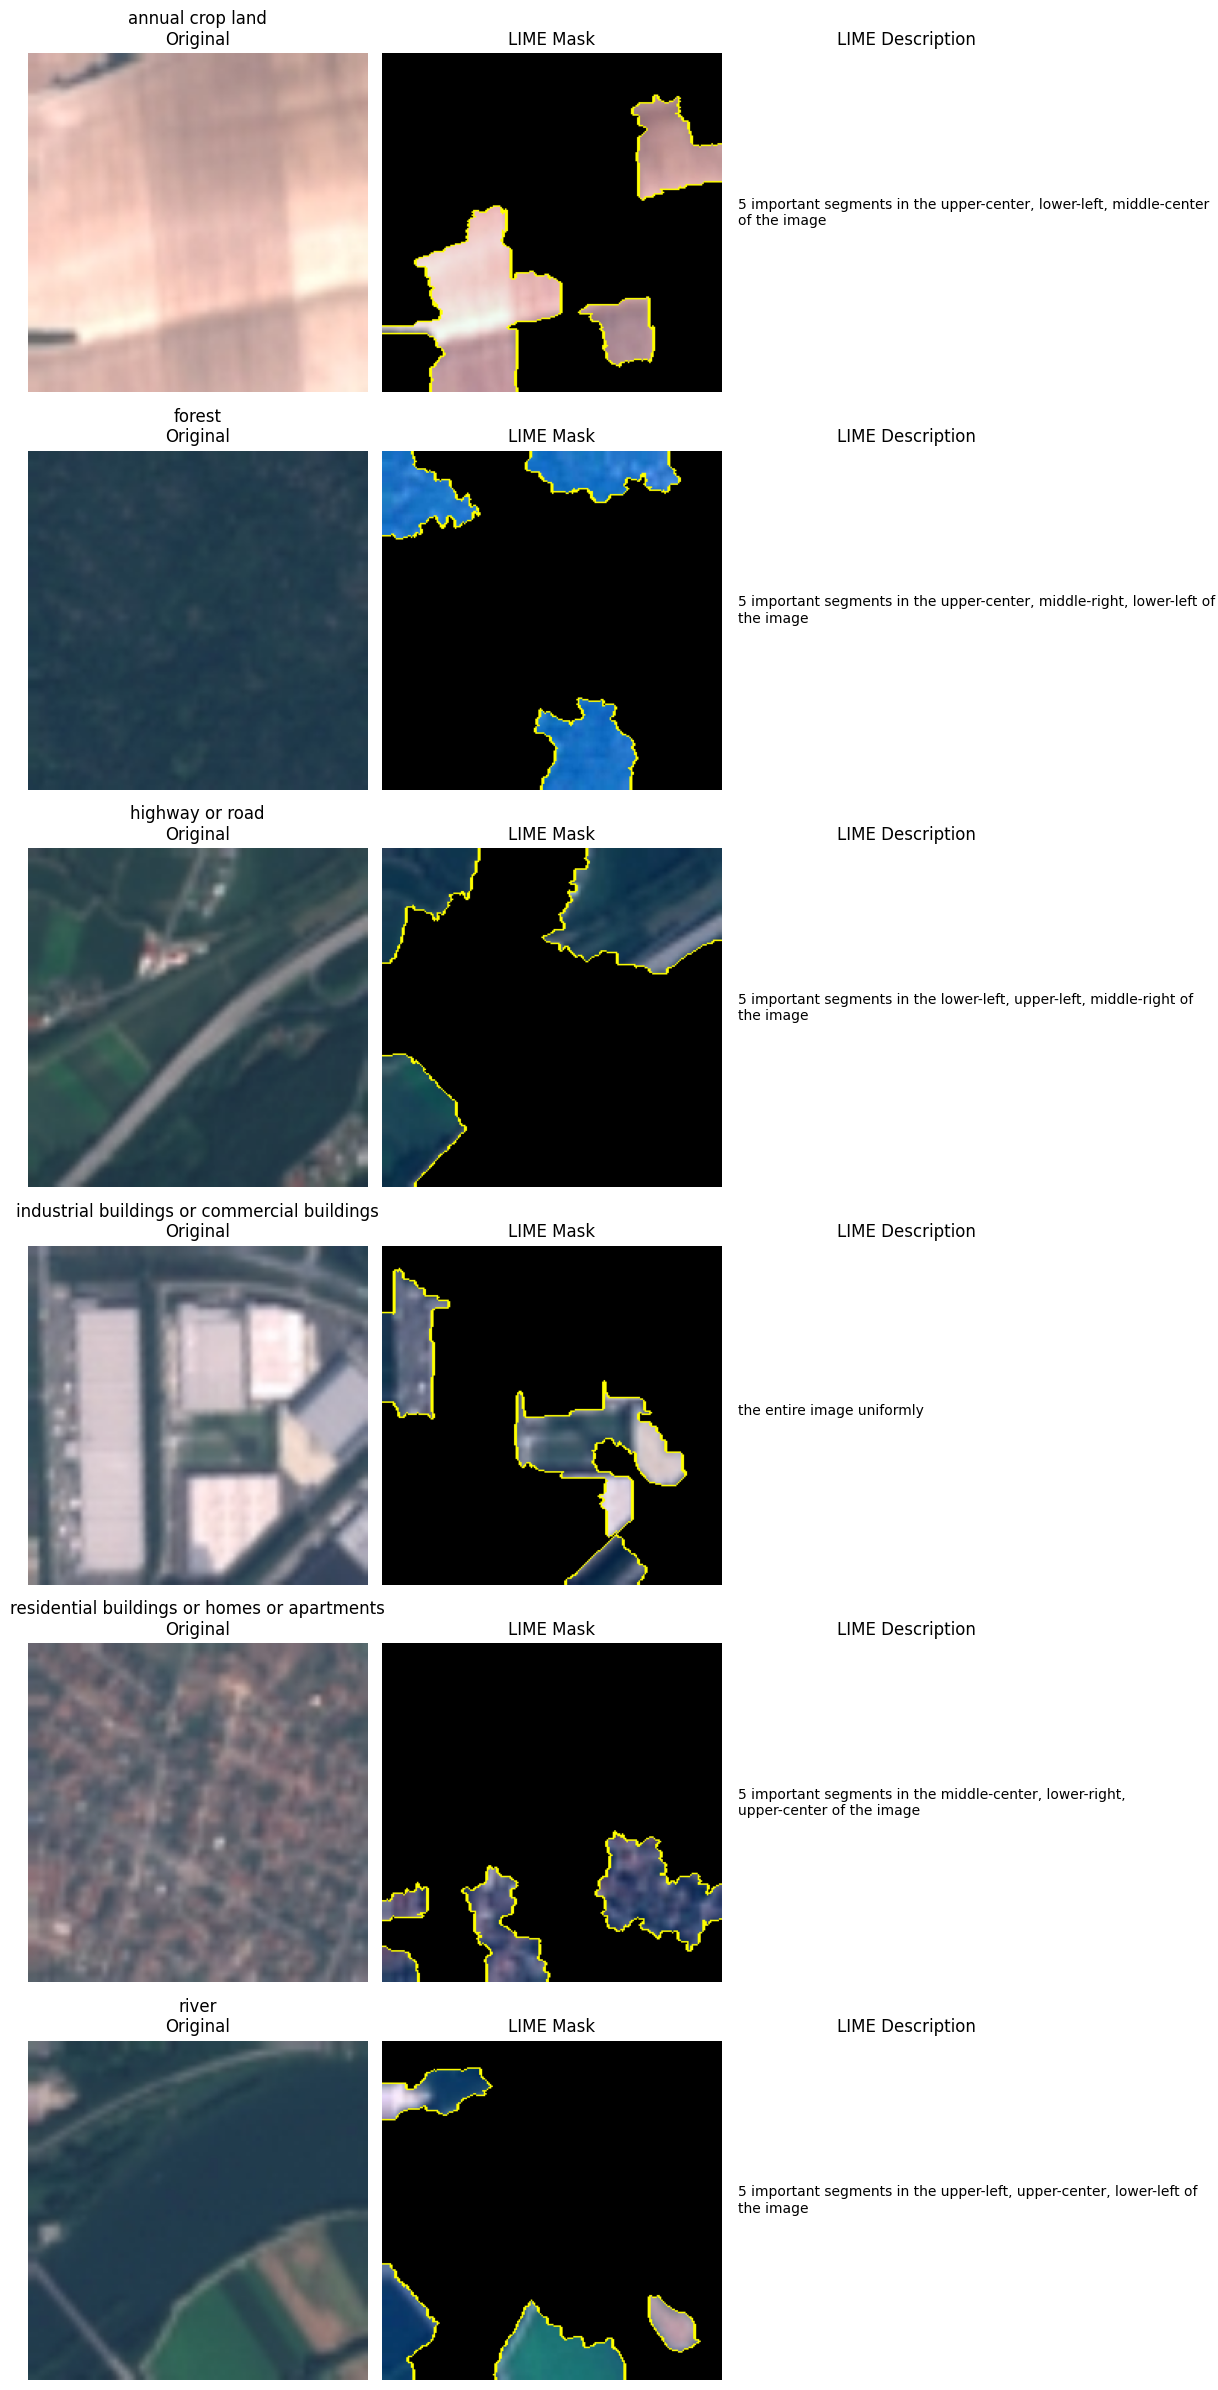

Saved figure to: lime_visualization.png


In [48]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

df = pd.read_csv("exp3_results_scaled.csv")

orig_base = "sample_images"
lime_base = "lime_masked_results"

fig, axes = plt.subplots(len(selected_classes), 3, figsize=(12, 4 * len(selected_classes)))

for row, class_name in enumerate(selected_classes):

    safe_class = class_name.replace(" ", "_").replace("/", "_")

    # Try common extensions
    possible_exts = ["png", "jpg", "jpeg"]

    orig_img_path = None
    for ext in possible_exts:
        path = os.path.join(orig_base, safe_class, f"{safe_class}_1.{ext}")
        if os.path.exists(path):
            orig_img_path = path
            break

    lime_img_path = None
    for ext in possible_exts:
        path = os.path.join(lime_base, safe_class, f"{safe_class}_lime_masked.{ext}")
        if os.path.exists(path):
            lime_img_path = path
            break

    if orig_img_path is None:
        raise FileNotFoundError(f"Original image not found for {class_name}")

    if lime_img_path is None:
        raise FileNotFoundError(f"LIME masked image not found for {class_name}")

    orig_img = Image.open(orig_img_path)
    lime_img = Image.open(lime_img_path)

    class_df = df[df["true_class"] == class_name]
    lime_text = class_df.iloc[0]["lime_description"]

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"{class_name}\nOriginal")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(lime_img)
    axes[row, 1].set_title("LIME Mask")
    axes[row, 1].axis("off")

    axes[row, 2].text(0.01, 0.5, lime_text, wrap=True, fontsize=10)
    axes[row, 2].set_title("LIME Description")
    axes[row, 2].axis("off")

plt.tight_layout()

save_path = "lime_visualization.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

## experiemnt with one sample per class

In [36]:
import os
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

save_base = "lime_results"
os.makedirs(save_base, exist_ok=True)

explainer = lime_image.LimeImageExplainer()

# Use selected_samples instead of filtering again
for class_name, sample in selected_samples.items():

    safe_class_name = class_name.replace(" ", "_").replace("/", "_")

    class_folder = os.path.join(save_base, safe_class_name)
    os.makedirs(class_folder, exist_ok=True)

    image_tensor = sample["image"]

    image_np = image_tensor.permute(1, 2, 0).numpy()

    image_np = (image_np - image_np.min()) / (
        image_np.max() - image_np.min()
    )
    
    image_np_255 = (image_np * 255).astype(np.uint8)
    
    image_np_255 = np.ascontiguousarray(image_np_255)
    
    explanation = explainer.explain_instance(
        image_np_255,
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=500,
        random_seed=42
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=True
    )

    lime_masked = mark_boundaries(temp / 255.0, mask)

    save_path = os.path.join(
        class_folder,
        f"{safe_class_name}_lime_masked.png"
    )

    plt.imsave(save_path, lime_masked)

    print(f"Saved: {save_path}")

print("\nAll 6 selected sample LIME images saved.")

  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_results/annual_crop_land/annual_crop_land_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_results/forest/forest_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

...

Saved: lime_results/industrial_buildings_or_commercial_buildings/industrial_buildings_or_commercial_buildings_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_results/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_lime_masked.png


  0%|          | 0/500 [00:00<?, ?it/s]

Saved: lime_results/river/river_lime_masked.png

All 6 selected sample LIME images saved.


In [39]:
print("Running Experiment 3 for 6 selected samples: Image + Prediction + LIME text\n")

lime_results_scaled = []
explainer = lime_image.LimeImageExplainer()

for class_name, sample in selected_samples.items():

    print(f"Processing class: {class_name}...")

    image_tensor = sample["image"]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # Convert image for LIME
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_np_255 = (image_np * 255).astype(np.uint8)

    # Run LIME
    explanation = explainer.explain_instance(
        image_np_255,
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=500,
        random_seed=42
    )

    # Get LIME description
    lime_description = describe_lime_regions(
        explanation,
        predicted
    )

    # Generate LLM explanation
    lime_explanation = get_lime_explanation(
        image_tensor,
        class_names[predicted],
        confidence,
        lime_description
    )

    lime_results_scaled.append({
        "true_class": class_name,
        "predicted_class": class_names[predicted],
        "confidence": round(confidence, 1),
        "lime_description": lime_description,
        "lime_explanation": lime_explanation
    })

    print(f"✓ {class_name} done")

print("\nAll 6 selected samples processed.")

Running Experiment 3 for 6 selected samples: Image + Prediction + LIME text

Processing class: annual crop land...


  0%|          | 0/500 [00:00<?, ?it/s]

✓ annual crop land done
Processing class: forest...


  0%|          | 0/500 [00:00<?, ?it/s]

✓ forest done
Processing class: highway or road...


...

✓ industrial buildings or commercial buildings done
Processing class: residential buildings or homes or apartments...


  0%|          | 0/500 [00:00<?, ?it/s]

✓ residential buildings or homes or apartments done
Processing class: river...


  0%|          | 0/500 [00:00<?, ?it/s]

✓ river done

All 6 selected samples processed.


In [40]:
df_lime_selected = pd.DataFrame(lime_results_scaled)
df_lime_selected.to_csv("lime_explanations_selected_samples.csv", index=False)

print("CSV saved: lime_explanations_selected_samples.csv")

CSV saved: lime_explanations_selected_samples.csv


## Experiment 4: Image + Prediction + SHAP text

### SHAP Version check

In [44]:
import shap
print(f"✓ SHAP version: {shap.__version__}")

✓ SHAP version: 0.51.0


### SHAP to Textual Conversion

In [41]:
# SHAP Region Description Function

def get_shap_values(image_tensor, predicted_class):

    # Prepare image for SHAP
    image_np = image_tensor.unsqueeze(0).cpu().numpy()

    # Define prediction function for SHAP
    def predict_fn(images):
        tensor = torch.FloatTensor(images).to(device)
        # Handle both NHWC and NCHW formats
        if tensor.shape[-1] == 3:
            tensor = tensor.permute(0, 3, 1, 2)
        with torch.no_grad():
            output = model(tensor)
            probs = torch.softmax(output, dim=1)
        return probs.cpu().numpy()

    # Use KernelSHAP with superpixel masker
    # Reshape image to NHWC for SHAP
    image_nhwc = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_nhwc = np.expand_dims(image_nhwc, axis=0)

    masker = shap.maskers.Image("inpaint_telea", image_nhwc[0].shape)

    explainer_shap = shap.Explainer(
        predict_fn,
        masker,
        output_names=class_names
    )

    shap_values = explainer_shap(
        image_nhwc,
        max_evals=500,
        batch_size=50,
        outputs=shap.Explanation.argsort.flip[:1]
    )

    return shap_values

def describe_shap_regions(shap_values, image_shape):

    # Get SHAP values for predicted class
    vals = shap_values.values[0, :, :, :, 0]

    # Average across color channels
    vals_mean = np.mean(np.abs(vals), axis=2)

    h, w = vals_mean.shape

    # Divide into 3x3 grid and find most important regions
    grid_scores = {}
    v_labels = ['upper', 'middle', 'lower']
    h_labels = ['left', 'center', 'right']

    for vi, v_label in enumerate(v_labels):
        for hi, h_label in enumerate(h_labels):
            y1 = vi * h // 3
            y2 = (vi + 1) * h // 3
            x1 = hi * w // 3
            x2 = (hi + 1) * w // 3
            grid_scores[f"{v_label}-{h_label}"] = vals_mean[y1:y2, x1:x2].mean()

    # Get top 3 regions
    top_regions = sorted(grid_scores.items(),
                         key=lambda x: x[1],
                         reverse=True)[:3]

    top_names = [r[0] for r in top_regions]
    intensity = vals_mean.max()
    focus = "strongly" if intensity > 0.01 else "moderately"

    return f"{top_names[0]} and {top_names[1]} regions, {focus} activated"

print("SHAP functions ready!")

SHAP functions ready!


### SHAP-Informed Description Function with LLM

In [42]:


def get_shap_explanation(image_tensor, predicted_class, confidence, shap_text):

    base64_image = tensor_to_base64(image_tensor)

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }

    payload = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    },
                    {
                        "type": "text",
                        "text": f"""You are given a satellite image and the prediction of a CNN model.
                                
                                The model predicted the class: "{predicted_class}".
                                
                                Additional information:
                                A SHAP analysis indicates that the model focused on the following regions: {shap_text}.
                                
                                Your task is to explain WHY the model made this prediction.
                                
                                Instructions:
                                - Use both the image and the highlighted region information
                                - Focus on visible features that support this prediction
                                - Be specific (shapes, textures, spatial patterns)
                                - Do NOT describe the scene in general terms
                                - Do NOT mention environmental or societal importance
                                - Do NOT mention SHAP explicitly
                                - Explain in a way that helps a human understand the model's reasoning"
                                
                                Keep the explanation concise (3–4 sentences)."""
                    }
                ]
            }
        ],
        "max_tokens": 200
    }

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers=headers,
        json=payload
    )

    return response.json()['choices'][0]['message']['content']

print("SHAP explanation function ready!")

SHAP explanation function ready!


### Run SHAP Experiment

In [43]:
print("Running Experiment 4: Image + Prediction + SHAP text\n")

shap_results_scaled = []

for class_idx in selected_indices:
    print(f"Processing class: {class_names[class_idx]}...")

    class_samples = val_data_large.filter(
        lambda x: x['label'] == class_idx
    ).select(range(20))

    for img_idx, sample in enumerate(class_samples):

        image_tensor = sample['image']
        input_tensor = image_tensor.unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            confidence = probs.max().item() * 100
            predicted = probs.argmax().item()

        # Get SHAP values
        shap_values = get_shap_values(image_tensor, predicted)

        # Get SHAP description
        shap_description = describe_shap_regions(
            shap_values,
            image_tensor.shape
        )

        # Generate explanation
        shap_explanation = get_shap_explanation(
            image_tensor,
            class_names[predicted],
            confidence,
            shap_description
        )

        shap_results_scaled.append({
            'true_class': class_names[class_idx],
            'predicted_class': class_names[predicted],
            'confidence': round(confidence, 1),
            'shap_description': shap_description,
            'shap_explanation': shap_explanation,
            'image_idx': img_idx
        })

    print(f"✓ {class_names[class_idx]} done — 20 images processed")


Running Experiment 4: Image + Prediction + SHAP text

Processing class: annual crop land...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.77s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:18, 18.16s/it]               


...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.90s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:25, 25.60s/it]               


✓ river done — 20 images processed


In [44]:

# Save results
shap_results_df = pd.DataFrame(shap_results_scaled)
shap_results_df.to_csv(f'exp4_results_scaled.csv', index=False)
print(f"\n✓ Experiment 4 complete!")
print(f"✓ Total results: {len(shap_results_df)} images")


✓ Experiment 4 complete!
✓ Total results: 120 images


### Example visualization

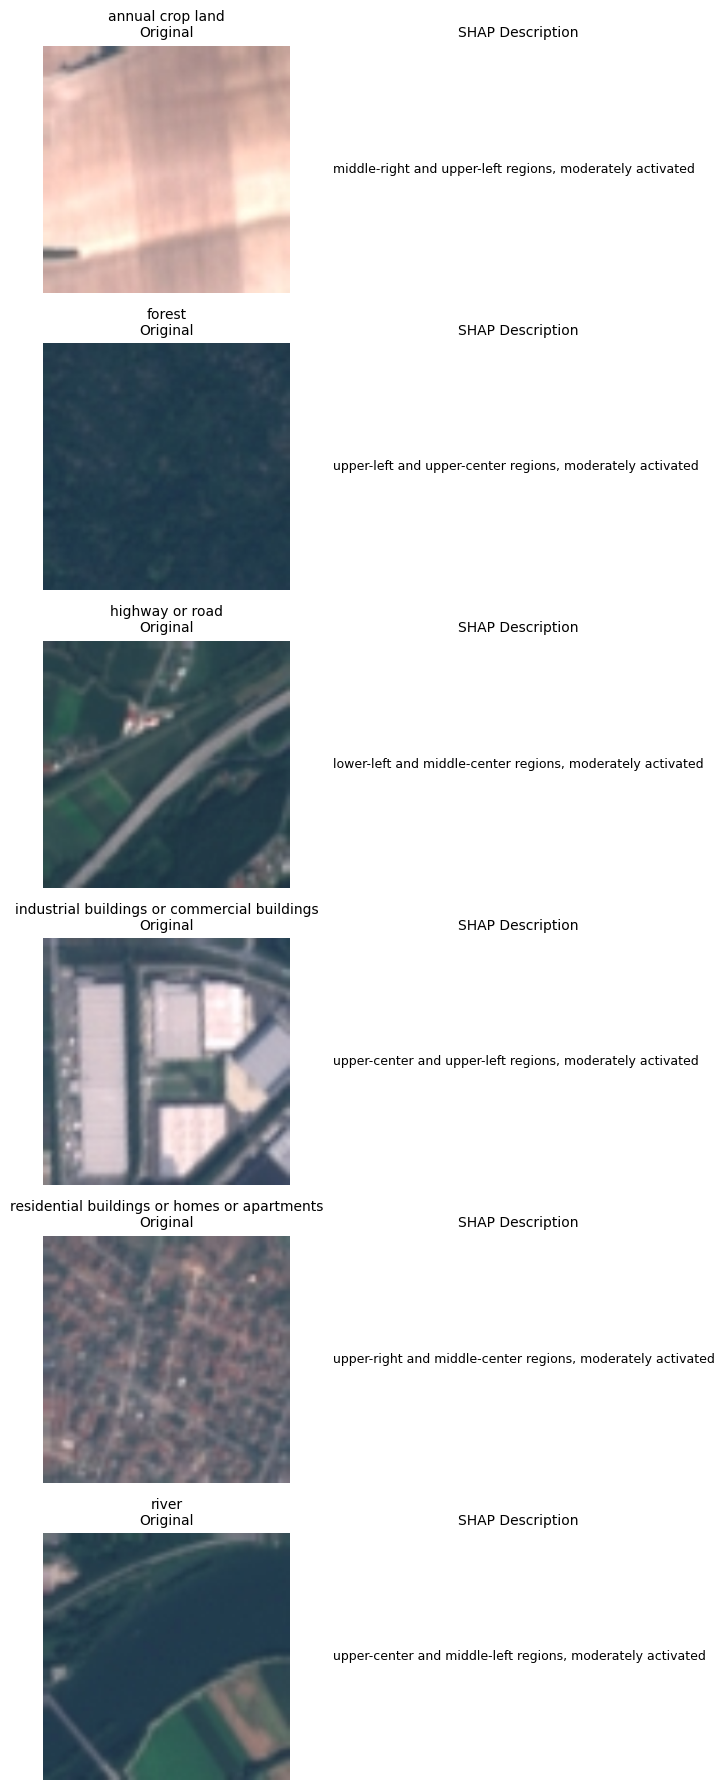

Saved figure to: shap_visualization.png


In [72]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

df = pd.read_csv("exp4_results_scaled.csv")

orig_base = "sample_images"

fig, axes = plt.subplots(len(selected_classes), 2, figsize=(8, 3 * len(selected_classes)))

if len(selected_classes) == 1:
    axes = [axes]

for row, class_name in enumerate(selected_classes):

    safe_class = class_name.replace(" ", "_").replace("/", "_")

    possible_exts = ["png", "jpg", "jpeg"]

    orig_img_path = None
    for ext in possible_exts:
        path = os.path.join(orig_base, safe_class, f"{safe_class}_1.{ext}")
        if os.path.exists(path):
            orig_img_path = path
            break

    if orig_img_path is None:
        raise FileNotFoundError(f"Original image not found for {class_name}")

    orig_img = Image.open(orig_img_path)

    class_df = df[df["true_class"] == class_name]

    if class_df.empty:
        raise ValueError(f"No SHAP description found for {class_name}")

    shap_text = class_df.iloc[0]["shap_description"]

    axes[row][0].imshow(orig_img)
    axes[row][0].set_title(f"{class_name}\nOriginal", fontsize=10)
    axes[row][0].axis("off")

    axes[row][1].text(
        0.01, 0.5,
        shap_text,
        wrap=True,
        fontsize=9,
        va="center"
    )
    axes[row][1].set_title("SHAP Description", fontsize=10)
    axes[row][1].axis("off")

plt.tight_layout()

save_path = "shap_visualization.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

### Experiment with one sample per class 

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt

save_base = "shap_overlay_results"
os.makedirs(save_base, exist_ok=True)

print("Saving SHAP overlays for 6 selected samples...\n")

for class_name, sample in selected_samples.items():

    print(f"Processing: {class_name}")

    safe_class_name = class_name.replace(" ", "_").replace("/", "_")

    class_folder = os.path.join(save_base, safe_class_name)
    os.makedirs(class_folder, exist_ok=True)

    image_tensor = sample["image"]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # SHAP values
    shap_values = get_shap_values(image_tensor, predicted)

    # Original image
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

    # SHAP heatmap
    vals = shap_values.values[0, :, :, :, 0]
    vals_mean = np.mean(np.abs(vals), axis=2)

    vals_mean = (vals_mean - vals_mean.min()) / (
        vals_mean.max() - vals_mean.min() + 1e-8
    )

    # Save overlay only
    save_path = os.path.join(
        class_folder,
        f"{safe_class_name}_shap_overlay.png"
    )

    plt.figure(figsize=(4, 4))
    plt.imshow(image_np)
    plt.imshow(vals_mean, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    print(f"Saved: {save_path}")

print("\nAll 6 SHAP overlays saved.")

Saving SHAP overlays for 6 selected samples...

Processing: annual crop land


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.91s/it]               


Saved: shap_overlay_results/annual_crop_land/annual_crop_land_shap_overlay.png
Processing: forest


  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer: 2it [00:11, 11.03s/it]               


Saved: shap_overlay_results/residential_buildings_or_homes_or_apartments/residential_buildings_or_homes_or_apartments_shap_overlay.png
Processing: river


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:16, 16.71s/it]               

Saved: shap_overlay_results/river/river_shap_overlay.png

All 6 SHAP overlays saved.


In [48]:
print("Running Experiment 4 for 6 selected samples: Image + Prediction + SHAP text\n")

shap_results_scaled = []

for class_name, sample in selected_samples.items():

    print(f"Processing class: {class_name}...")

    image_tensor = sample["image"]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence = probs.max().item() * 100
        predicted = probs.argmax().item()

    # Get SHAP values
    shap_values = get_shap_values(image_tensor, predicted)

    # Get SHAP description
    shap_description = describe_shap_regions(
        shap_values,
        image_tensor.shape
    )

    # Generate SHAP explanation
    shap_explanation = get_shap_explanation(
        image_tensor,
        class_names[predicted],
        confidence,
        shap_description
    )

    shap_results_scaled.append({
        "true_class": class_name,
        "predicted_class": class_names[predicted],
        "confidence": round(confidence, 1),
        "shap_description": shap_description,
        "shap_explanation": shap_explanation
    })

    print(f"✓ {class_name} done")

print("\nAll 6 selected samples processed.")

Running Experiment 4 for 6 selected samples: Image + Prediction + SHAP text

Processing class: annual crop land...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.88s/it]               


✓ annual crop land done
Processing class: forest...


  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer: 2it [00:10, 10.69s/it]               


✓ residential buildings or homes or apartments done
Processing class: river...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:16, 16.91s/it]               


✓ river done

All 6 selected samples processed.


In [49]:
df_shap_selected = pd.DataFrame(shap_results_scaled)
df_shap_selected.to_csv("shap_explanations_selected_samples.csv", index=False)

print("CSV saved: shap_explanations_selected_samples.csv")

CSV saved: shap_explanations_selected_samples.csv
